<a href="https://colab.research.google.com/github/sayak395/Jaynes-Cummings-model/blob/main/Clean_Parameterisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
!pip install qutip

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from qutip import (basis, destroy, mesolve, qeye, tensor, create, sigmaz, sigmam, sigmap, fock, Qobj, fidelity, Options)
from scipy.signal import find_peaks

from scipy.interpolate import CubicSpline, PchipInterpolator
!pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.plots import plot_convergence
from skopt.utils import use_named_args

from skopt.plots import plot_convergence, plot_objective, plot_evaluations

In [26]:
# Hilbert space dimension for the cavity
n_cavity = 5
sigma_z_np = np.array([[1 , 0],
                   [0, -1]])
sigma_z_alt = Qobj(sigma_z_np)
sigma_plus_np = np.array([[0, 1],
                   [0, 0]])
sigma_plus_alt = Qobj(sigma_plus_np)
sigma_minus_np = np.transpose(sigma_plus_np)
sigma_minus_alt = Qobj(sigma_minus_np)

###########################
# Define the Operators
###########################

sigma_minus = tensor(qeye(n_cavity), sigma_minus_alt) # atomic lowering operator
sigma_plus =  tensor(qeye(n_cavity), sigma_plus_alt)  # atomic raising operator
sigma_z = tensor(qeye(n_cavity), sigma_z_alt)     # atomic z operator
a = tensor(destroy(n_cavity), qeye(2))   # cavity annihilation operator
spin_down = fock(2, 1)
spin_up = fock(2, 0)

wc = wa = 1.0  # Example values
w0 = wc # resonance driving
delta_c = (wc - w0)/wc
delta_a = (wa - w0)/wc
g = 0.01 * wc

In [14]:
psi = tensor(fock(n_cavity, 0), spin_down)
psi_den = psi * psi.dag()
target_state = tensor(fock(n_cavity, 1), spin_down)
target_den = target_state * target_state.dag()

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 1.2282
Function value obtained: -0.0546
Current minimum: -0.0546
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 1.2177
Function value obtained: -0.0015
Current minimum: -0.0546
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 0.5038
Function value obtained: -0.4237
Current minimum: -0.4237
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 0.7009
Function value obtained: -0.0976
Current minimum: -0.4237
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 1.1052
Function value obtained: -0.0041
Current minimum: -0.4237
Iteration No: 6 started. 

AssertionError: 

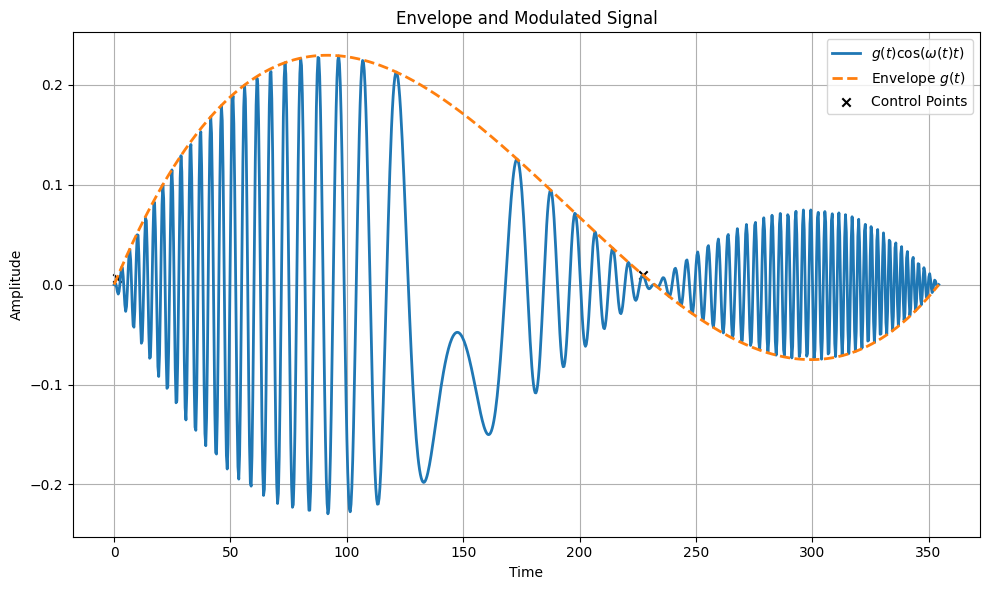

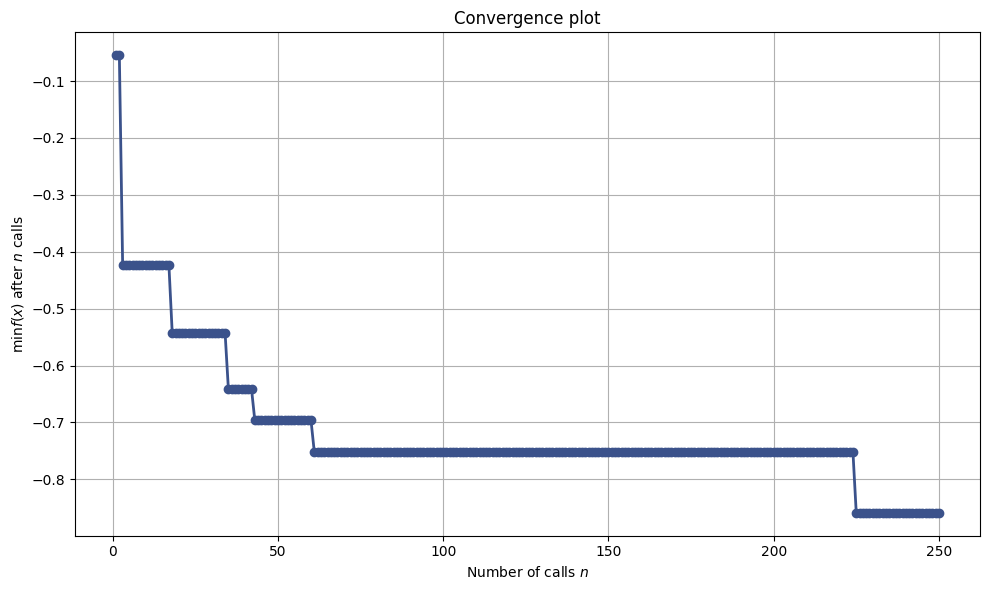

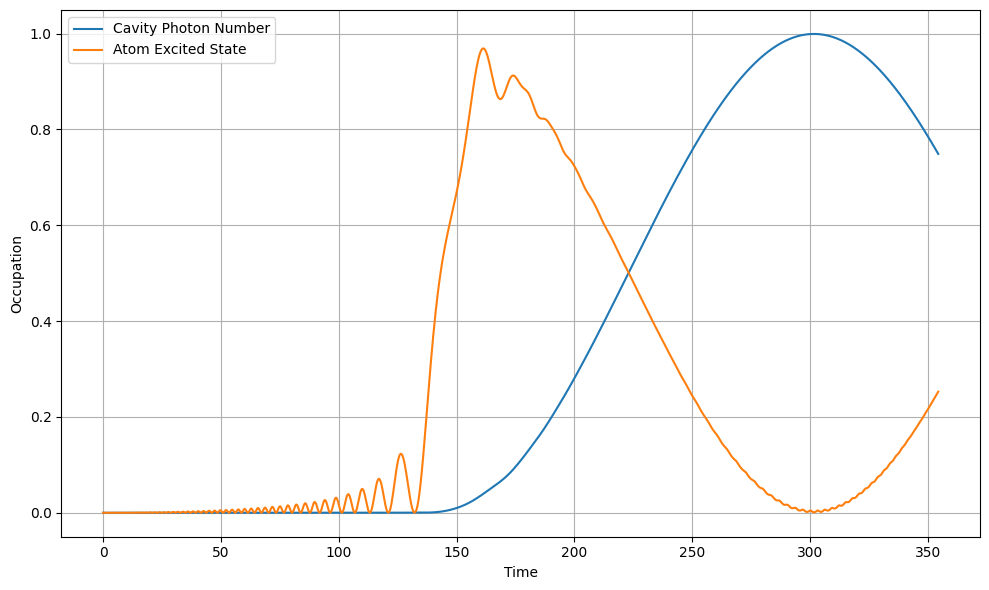

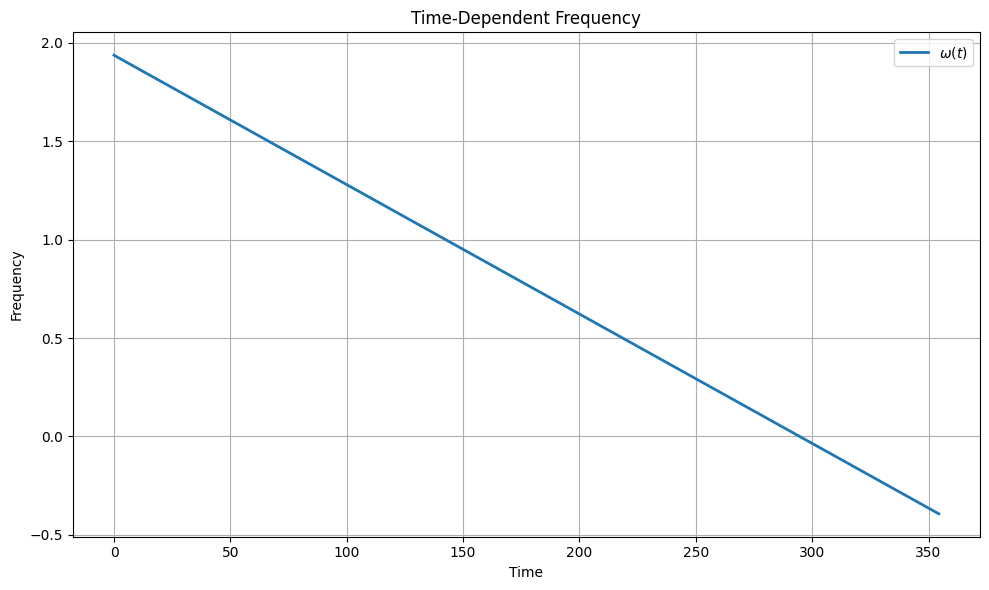

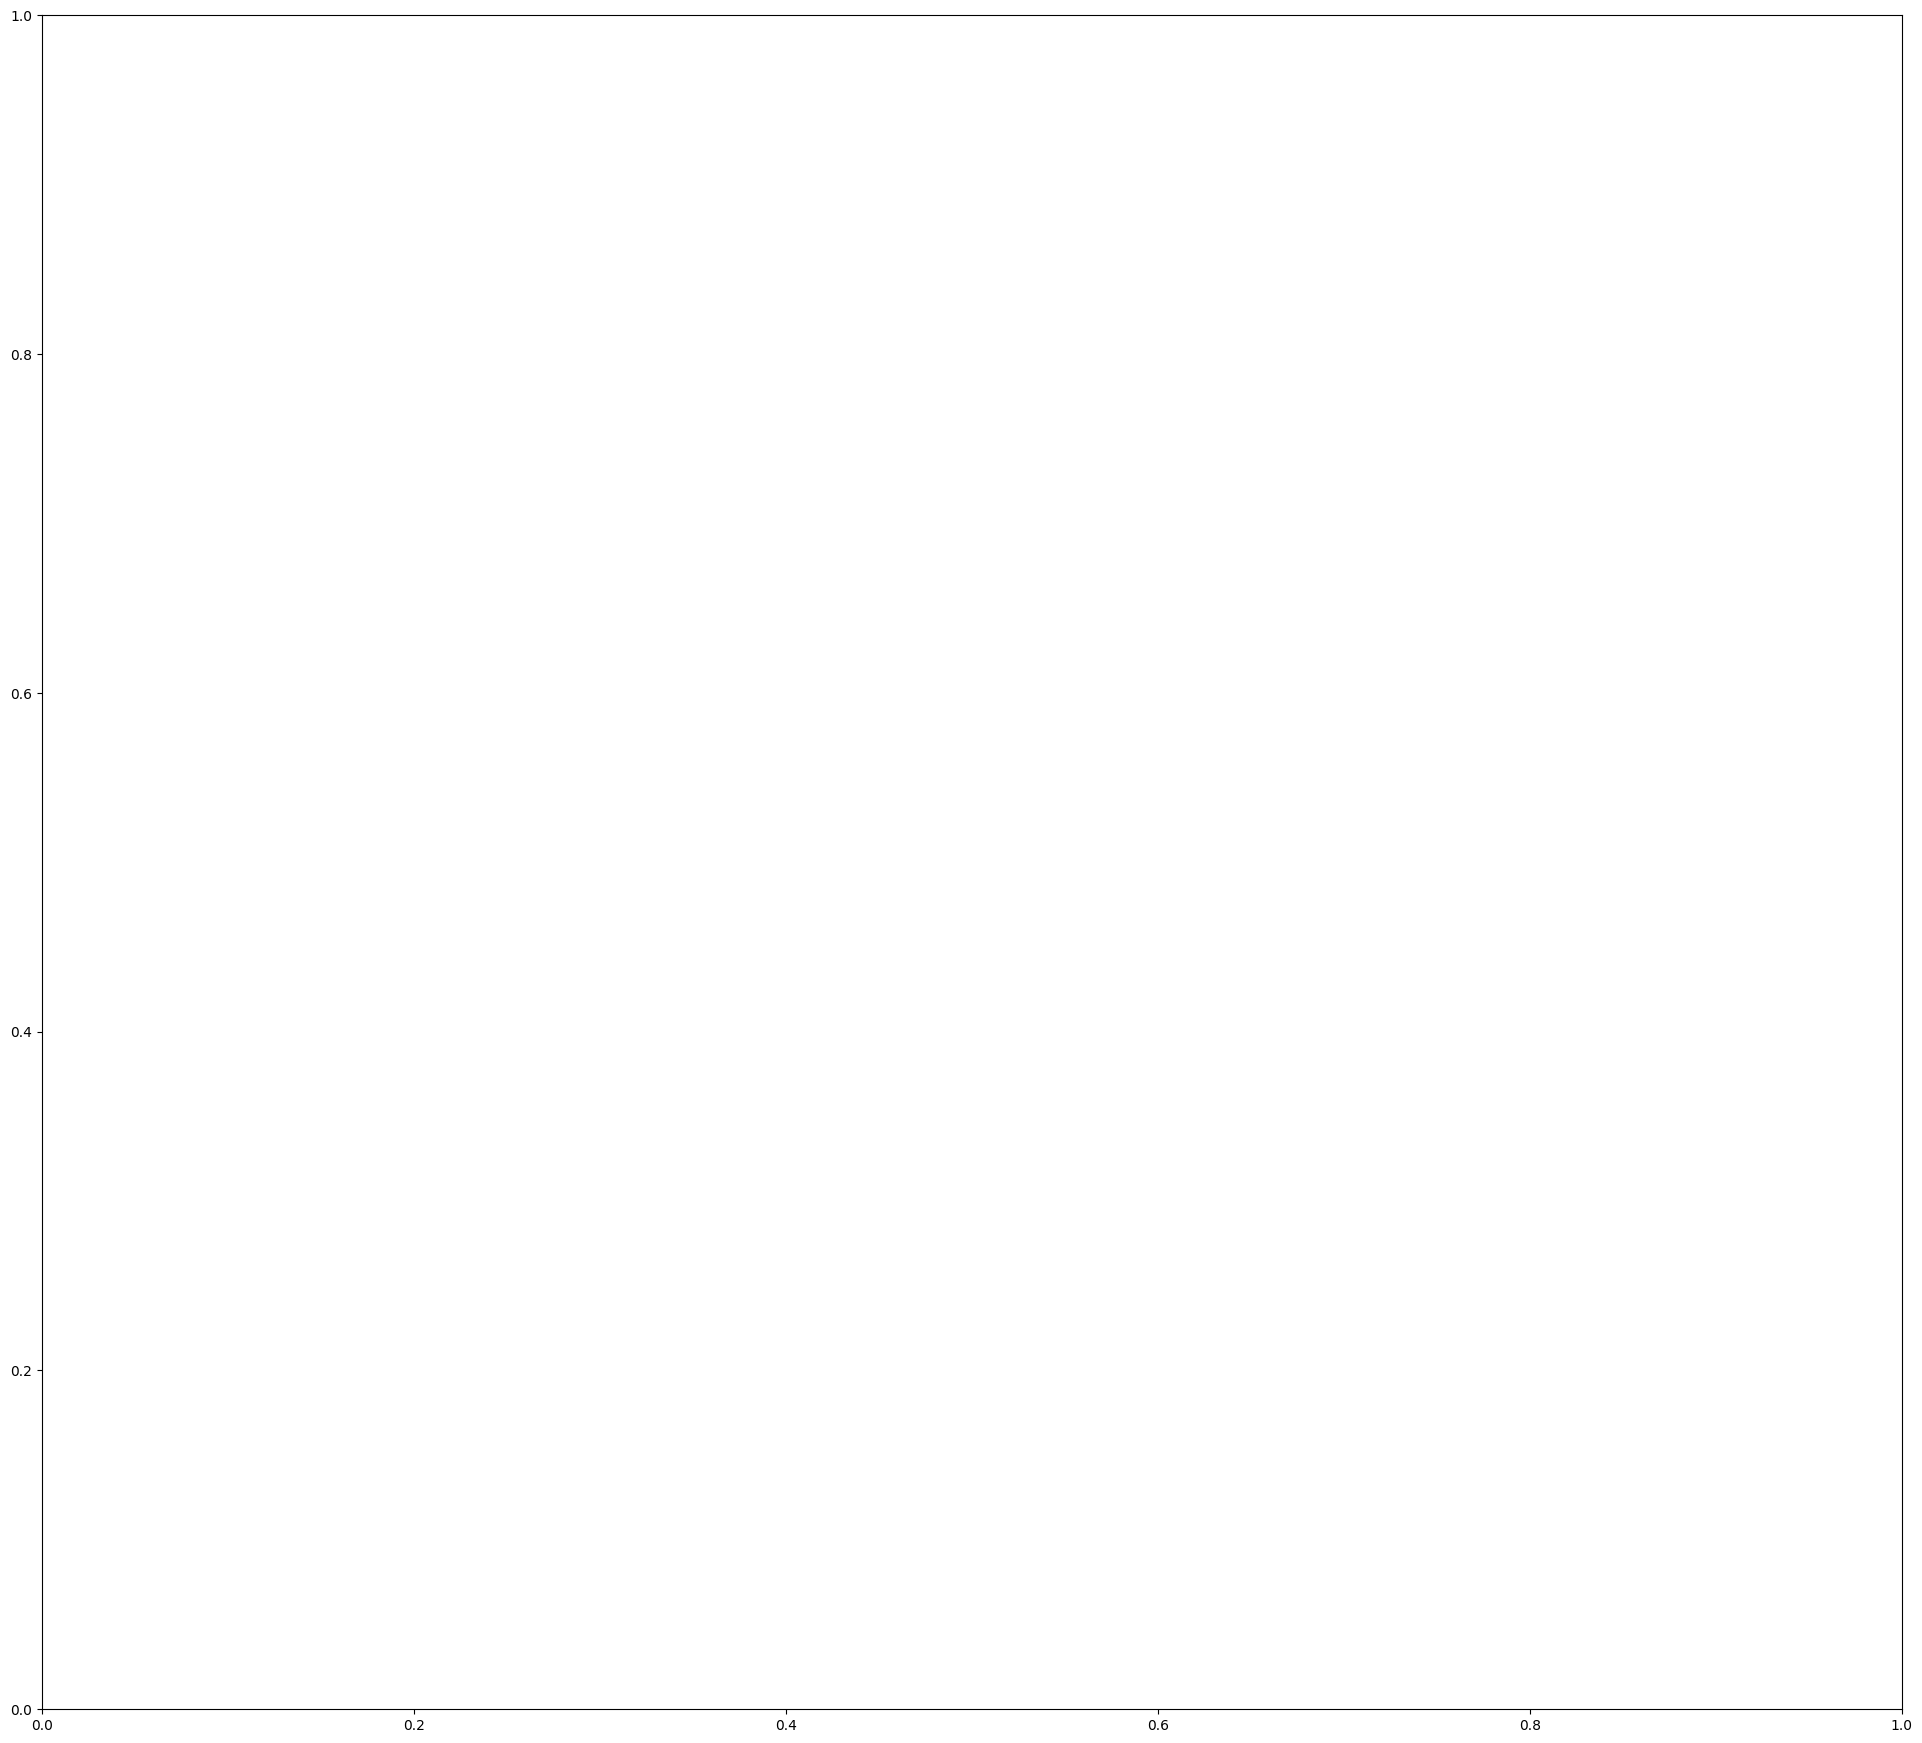

In [16]:
# Define your f_t modulation function
def f_t(t, args):
    g_t = args['envelope'](t)
    omega_t = args['frequency'](t)
    return g_t * np.cos(omega_t * t)

# Define your search space with normalized time deltas
space = [
    Real(-g, g),         # envelope_y1
    Real(-g, g),         # envelope_y2
    Real(0, 1),          # delta_ex1
    Real(0, 1),          # delta_ex2
    Real(1/g, 3000),         # sim_time

    Real(0, 1.0),        # freq1
    Real(0, 1.0),        # freq2


    Real(0, 1/2),        # fx1
    Real(0, 1/2),        # fx2

]

def run_optimization_and_analysis(f_t, space, plot=True, n_calls=250, random_state=42):
    def objective_general(envelope_y1, envelope_y2, delta_ex1, delta_ex2, sim_time,
                          freq1, freq2, fx1, fx2):

        tau = wc * sim_time
        envelope_x1 = tau * min(delta_ex1, delta_ex2)
        envelope_x2 = tau * max(delta_ex1, delta_ex2)

        freq_x1 = tau * fx1
        freq_x2 = tau * (fx1 + fx2)

        if not (0 < envelope_x1 < envelope_x2 < tau):
            return 1.0
        if not (0 < freq_x1 < freq_x2 < tau):
            return 1.0

        envelope_values = [0, envelope_y1, envelope_y2, 0]
        control_times = [0, envelope_x1, envelope_x2, tau]
        spline = CubicSpline(control_times, envelope_values, extrapolate=False)

        freq_times = [freq_x1, freq_x2]
        freq_values = [freq1, freq2]
        frequency_spline = PchipInterpolator(freq_times, freq_values)

        args = {'envelope': spline, 'frequency': frequency_spline, 'sim_time': sim_time}

        H_static = delta_c * a.dag() * a + 0.5 * delta_a * sigma_z + (g / wc) * (sigma_plus * a + sigma_minus * a.dag())
        H_drive = [0.5 * (sigma_plus + sigma_minus), lambda t: f_t(t, args)]
        H = [H_static, H_drive]

        try:
            result = mesolve(H, psi_den, [0, tau], c_ops=[], e_ops=[],
                             options={'nsteps': 1e8, 'atol': 1e-7, 'rtol': 1e-7})
            final_rho = result.states[-1]
            fid = fidelity(final_rho, target_den)
            return -fid
        except Exception as e:
            print("Simulation error:", e)
            return 1.0

    def objective(x):
        return objective_general(*x)

    res = gp_minimize(objective, space, n_calls=n_calls, random_state=random_state, verbose=True, acq_func='EI')

    if plot:
        (Y1, Y2, delta_X1, delta_X2, sim_time,
         freq1, freq2, fx1, fx2) = res.x

        tau = wc * sim_time
        X1 = tau * min(delta_X1, delta_X2)
        X2 = tau * max(delta_X1, delta_X2)
        freq_x1 = tau * fx1
        freq_x2 = tau * (fx1 + fx2)

        tau_arr = np.linspace(0, tau, 1000)
        envelope_spline = CubicSpline([0, X1, X2, tau], [0, Y1, Y2, 0], extrapolate=False)
        frequency_spline = PchipInterpolator([freq_x1, freq_x2], [freq1, freq2])
        envelope = envelope_spline(tau_arr)
        omega_t = frequency_spline(tau_arr)

        # Plot 1: Modulated wave and envelope
        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, envelope * np.cos(omega_t * tau_arr), label=r'$g(t)\cos(\omega(t)t)$', linewidth=2)
        plt.plot(tau_arr, envelope, label=r'Envelope $g(t)$', linestyle='--', linewidth=2)
        plt.scatter([X1, X2], [Y1, Y2], marker='x', color='black', label='Control Points')
        plt.title('Envelope and Modulated Signal')
        plt.xlabel('Time')
        plt.ylabel('Amplitude')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        # Plot 2: Convergence
        plt.figure(figsize=(10, 6))
        plot_convergence(res)
        plt.tight_layout()


        # Plot 4: Population dynamics
        args = {'envelope': envelope_spline, 'frequency': frequency_spline}
        H_static = delta_c * a.dag() * a + 0.5 * delta_a * sigma_z + (g / wc) * (sigma_plus * a + sigma_minus * a.dag())
        H_drive = [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t(t, args)]
        H = [H_static, H_drive]
        output = mesolve(H, psi, tau_arr, c_ops=[], e_ops=[a.dag() * a, sigma_plus * sigma_minus], args=args)
        n_c = output.expect[0]
        n_a = output.expect[1]

        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, n_c, label='Cavity Photon Number')
        plt.plot(tau_arr, n_a, label='Atom Excited State')
        plt.xlabel('Time')
        plt.ylabel('Occupation')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        # Plot 5: ω(t)
        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, omega_t, label=r'$\omega(t)$', linewidth=2)
        plt.title('Time-Dependent Frequency')
        plt.xlabel('Time')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        # Plot 3: Objective landscape with shared colorbar
        fig, ax = plt.subplots(figsize=(24, 22))
        ax = plot_objective(res, dimensions=[
        'Y1', 'Y2', 'ΔX1', 'ΔX2', 'SimTime',
        'Freq1', 'Freq2', 'FX1', 'FX2'
        ], n_points=20, levels=20)

        # Add colorbar using the last contour in the last axis (if present)
        if isinstance(ax, np.ndarray):
            target_ax = ax.ravel()[-1]
        else:
            target_ax = ax

        if hasattr(target_ax, 'collections') and target_ax.collections:
            fig.colorbar(target_ax.collections[0], ax=fig.axes, shrink=0.8)

        plt.tight_layout()

    return res

# Now call the function
res = run_optimization_and_analysis(f_t, space)


Attempting to go to 2 down

In [23]:

psi = tensor(fock(n_cavity, 0), spin_down)
psi_den = psi * psi.dag()
target_state = tensor(fock(n_cavity, 2), spin_down)
target_den = target_state * target_state.dag()

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 1.0179
Function value obtained: -0.0001
Current minimum: -0.0001
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 1.2325
Function value obtained: -0.0000
Current minimum: -0.0001
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 0.3013
Function value obtained: -0.0004
Current minimum: -0.0004
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 0.8001
Function value obtained: -0.0006
Current minimum: -0.0006
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 1.5084
Function value obtained: -0.0002
Current minimum: -0.0006
Iteration No: 6 started. 

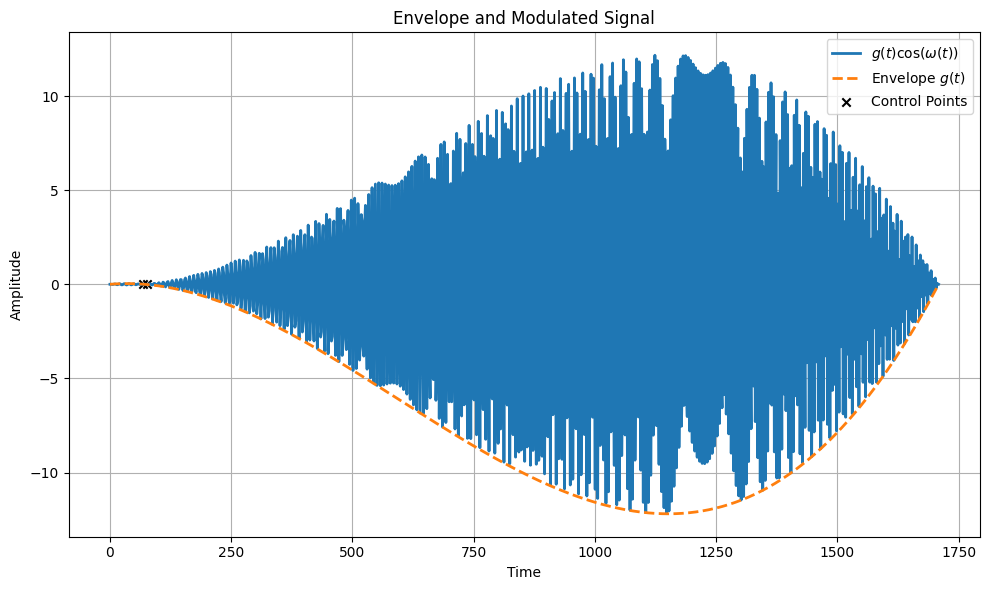

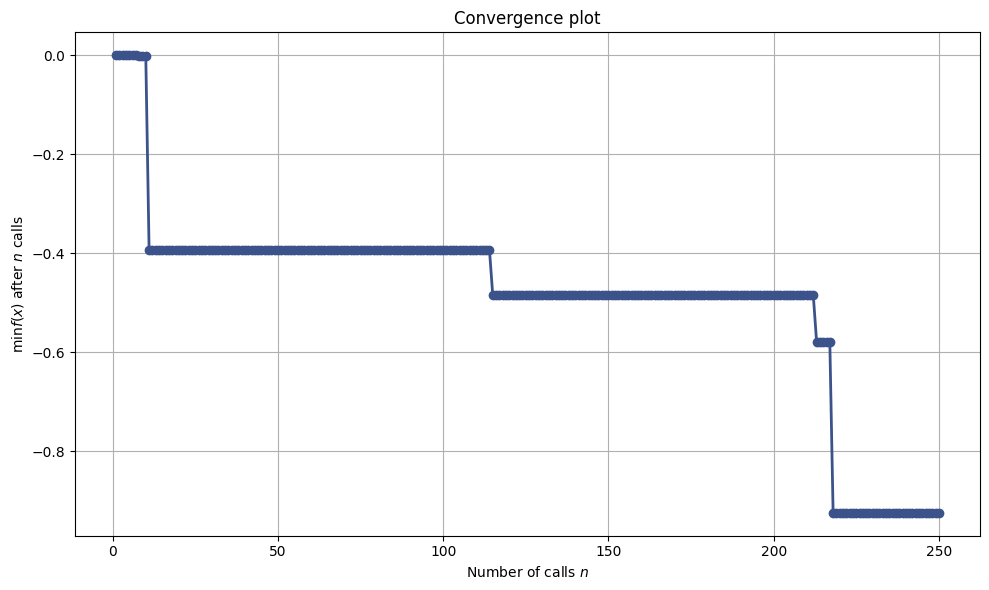

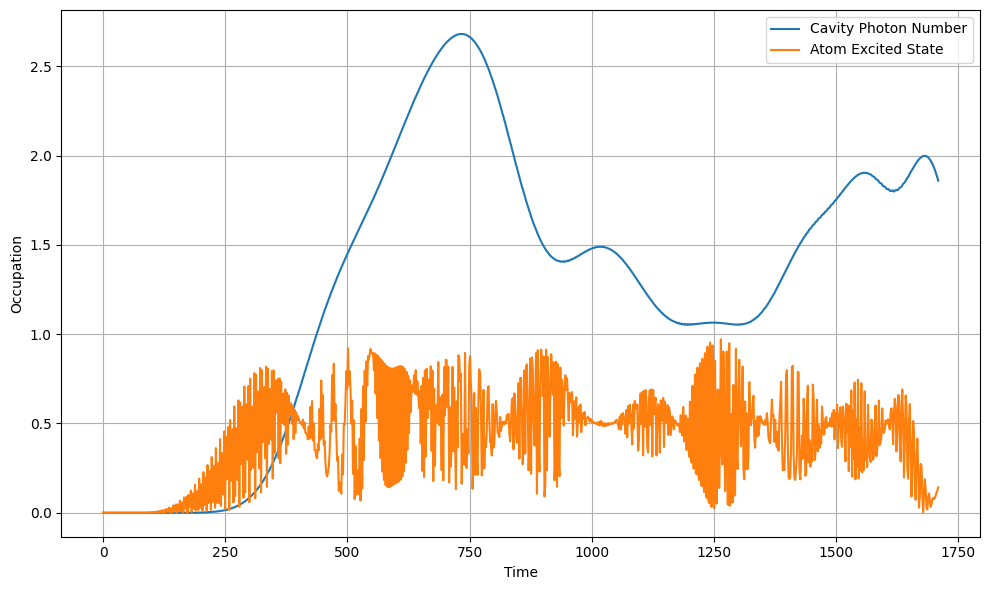

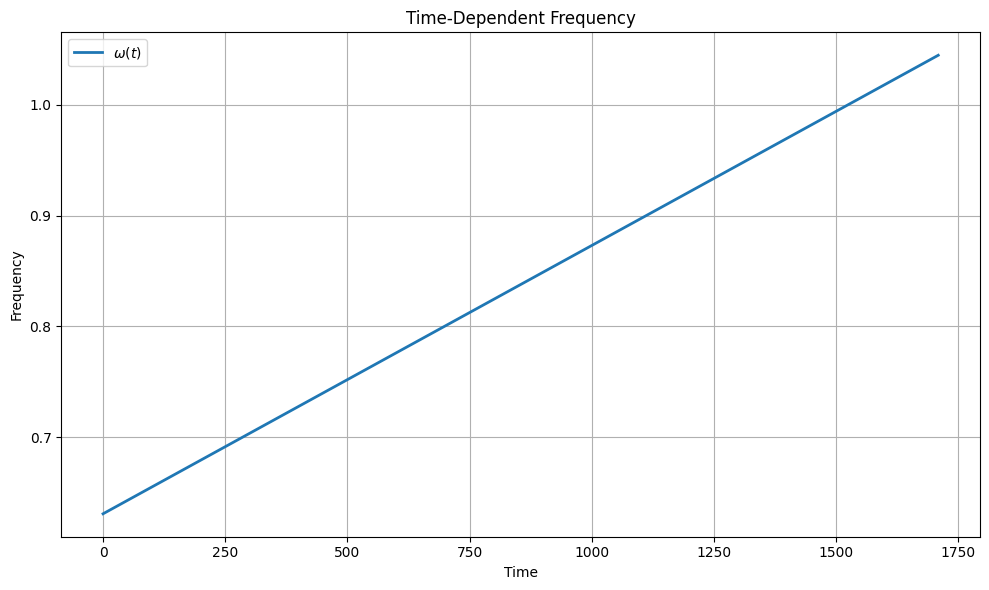

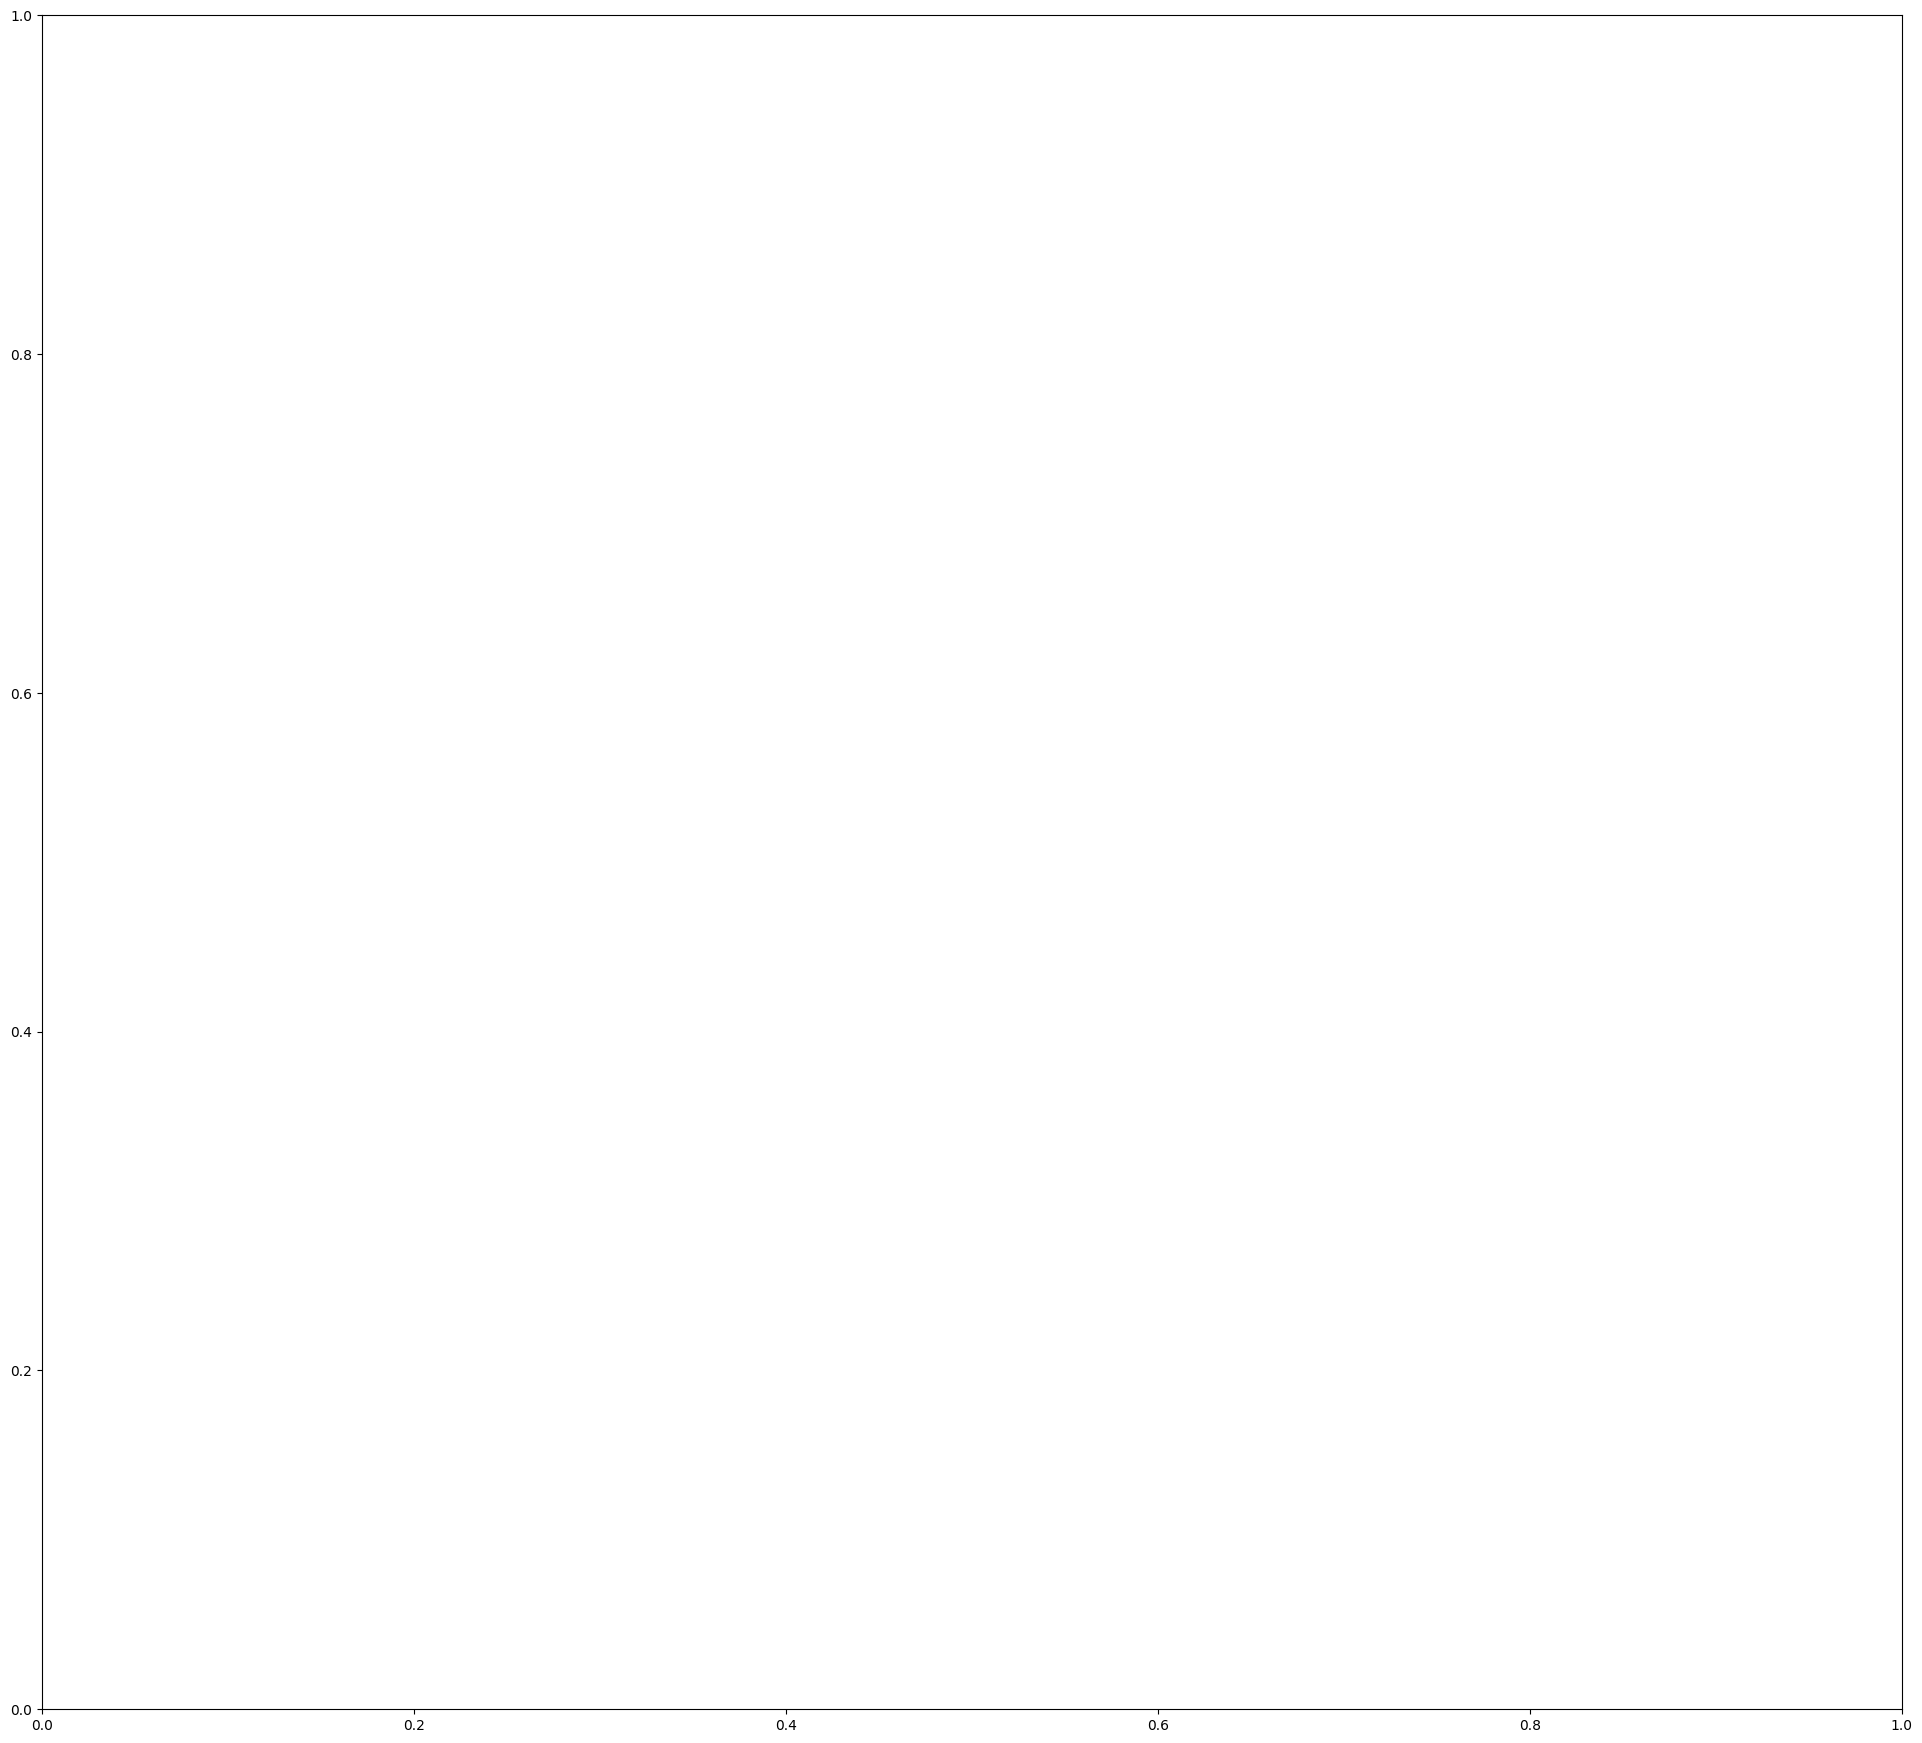

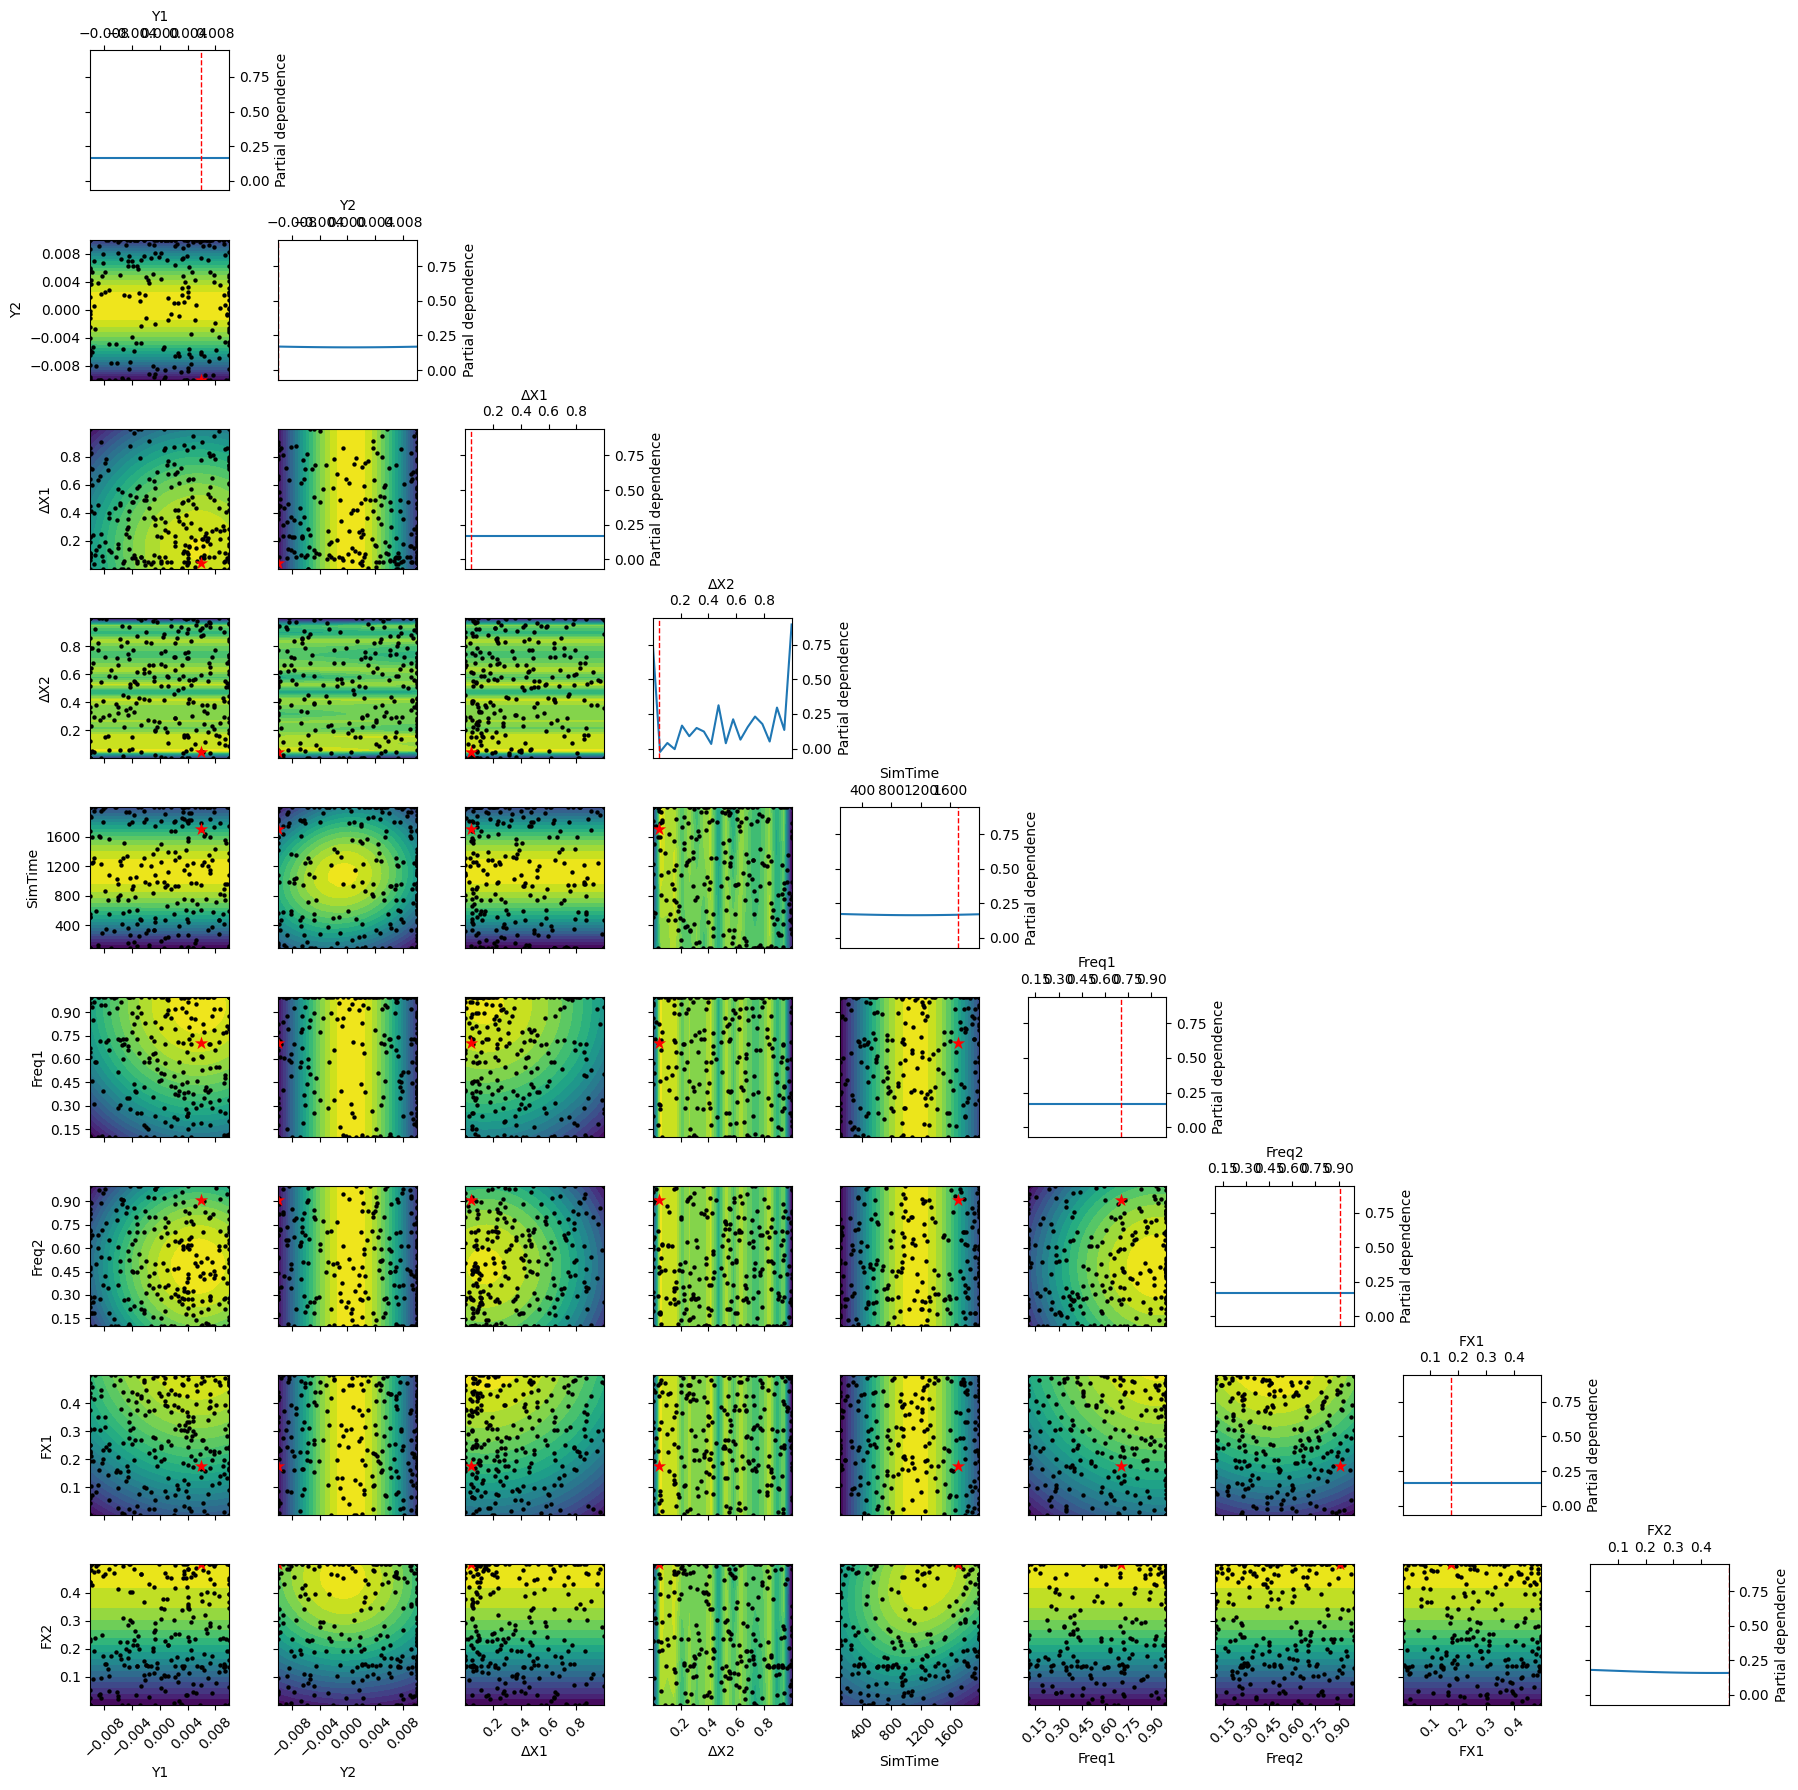

In [24]:
# Define your f_t modulation function
def f_t(t, args):
    g_t = args['envelope'](t)
    omega_t = args['frequency'](t)
    return g_t * np.cos(omega_t * t)

# Define your search space with normalized time deltas
space = [
    Real(-g, g),         # envelope_y1
    Real(-g, g),         # envelope_y2
    Real(0, 1),          # delta_ex1
    Real(0, 1),          # delta_ex2
    Real(1/g, 2000),         # sim_time

    Real(0.1, 1.0),        # freq1
    Real(0.1, 1.0),        # freq2


    Real(0, 1/2),        # fx1
    Real(0, 1/2),        # fx2

]

def run_optimization_and_analysis(f_t, space, plot=True, n_calls=250, random_state=42):
    def objective_general(envelope_y1, envelope_y2, delta_ex1, delta_ex2, sim_time,
                          freq1, freq2, fx1, fx2):

        tau = wc * sim_time
        envelope_x1 = tau * min(delta_ex1, delta_ex2)
        envelope_x2 = tau * max(delta_ex1, delta_ex2)

        freq_x1 = tau * fx1
        freq_x2 = tau * (fx1 + fx2)

        if not (0 < envelope_x1 < envelope_x2 < tau):
            return 1.0
        if not (0 < freq_x1 < freq_x2 < tau):
            return 1.0

        envelope_values = [0, envelope_y1, envelope_y2, 0]
        control_times = [0, envelope_x1, envelope_x2, tau]
        spline = CubicSpline(control_times, envelope_values, extrapolate=False)

        freq_times = [freq_x1, freq_x2]
        freq_values = [freq1, freq2]
        frequency_spline = PchipInterpolator(freq_times, freq_values)

        args = {'envelope': spline, 'frequency': frequency_spline, 'sim_time': sim_time}

        H_static = delta_c * a.dag() * a + 0.5 * delta_a * sigma_z + (g / wc) * (sigma_plus * a + sigma_minus * a.dag())
        H_drive = [0.5 * (sigma_plus + sigma_minus), lambda t: f_t(t, args)]
        H = [H_static, H_drive]

        try:
            result = mesolve(H, psi_den, [0, tau], c_ops=[], e_ops=[],
                             options={'nsteps': 1e8, 'atol': 1e-7, 'rtol': 1e-7})
            final_rho = result.states[-1]
            fid = fidelity(final_rho, target_den)
            return -fid
        except Exception as e:
            print("Simulation error:", e)
            return 1.0

    def objective(x):
        return objective_general(*x)

    res = gp_minimize(objective, space, n_calls=n_calls, random_state=random_state, verbose=True, acq_func='EI')

    if plot:
        (Y1, Y2, delta_X1, delta_X2, sim_time,
         freq1, freq2, fx1, fx2) = res.x

        tau = wc * sim_time
        X1 = tau * min(delta_X1, delta_X2)
        X2 = tau * max(delta_X1, delta_X2)
        freq_x1 = tau * fx1
        freq_x2 = tau * (fx1 + fx2)

        tau_arr = np.linspace(0, tau, 1000)
        envelope_spline = CubicSpline([0, X1, X2, tau], [0, Y1, Y2, 0], extrapolate=False)
        frequency_spline = PchipInterpolator([freq_x1, freq_x2], [freq1, freq2])
        envelope = envelope_spline(tau_arr)
        omega_t = frequency_spline(tau_arr)

        # Plot 1: Modulated wave and envelope
        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, envelope * np.cos(omega_t * tau_arr), label=r'$g(t)\cos(\omega(t))$', linewidth=2)
        plt.plot(tau_arr, envelope, label=r'Envelope $g(t)$', linestyle='--', linewidth=2)
        plt.scatter([X1, X2], [Y1, Y2], marker='x', color='black', label='Control Points')
        plt.title('Envelope and Modulated Signal')
        plt.xlabel('Time')
        plt.ylabel('Amplitude')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        # Plot 2: Convergence
        plt.figure(figsize=(10, 6))
        plot_convergence(res)
        plt.tight_layout()


        # Plot 4: Population dynamics
        args = {'envelope': envelope_spline, 'frequency': frequency_spline}
        H_static = delta_c * a.dag() * a + 0.5 * delta_a * sigma_z + (g / wc) * (sigma_plus * a + sigma_minus * a.dag())
        H_drive = [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t(t, args)]
        H = [H_static, H_drive]
        output = mesolve(H, psi, tau_arr, c_ops=[], e_ops=[a.dag() * a, sigma_plus * sigma_minus], args=args)
        n_c = output.expect[0]
        n_a = output.expect[1]

        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, n_c, label='Cavity Photon Number')
        plt.plot(tau_arr, n_a, label='Atom Excited State')
        plt.xlabel('Time')
        plt.ylabel('Occupation')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        # Plot 5: ω(t)
        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, omega_t, label=r'$\omega(t)$', linewidth=2)
        plt.title('Time-Dependent Frequency')
        plt.xlabel('Time')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        # Plot 3: Objective landscape with shared colorbar
        fig, ax = plt.subplots(figsize=(24, 22))
        ax = plot_objective(res, dimensions=[
        'Y1', 'Y2', 'ΔX1', 'ΔX2', 'SimTime',
        'Freq1', 'Freq2', 'FX1', 'FX2'
        ], n_points=20, levels=20)

        # Add colorbar using the last contour in the last axis (if present)
        if isinstance(ax, np.ndarray):
            target_ax = ax.ravel()[-1]
        else:
            target_ax = ax

        if hasattr(target_ax, 'collections') and target_ax.collections:
            fig.colorbar(target_ax.collections[0], ax=fig.axes, shrink=0.8)

        plt.tight_layout()

    return res

# Now call the function
res = run_optimization_and_analysis(f_t, space)


Now we can try to get to 3 down and see what happens.

In [27]:
psi = tensor(fock(n_cavity, 0), spin_down)
psi_den = psi * psi.dag()
target_state = tensor(fock(n_cavity, 3), spin_down)
target_den = target_state * target_state.dag()

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 3.0794
Function value obtained: -0.0000
Current minimum: -0.0000
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 1.3477
Function value obtained: -0.0000
Current minimum: -0.0000
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 0.5190
Function value obtained: -0.0002
Current minimum: -0.0002
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 1.2446
Function value obtained: -0.0000
Current minimum: -0.0002
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 4.4895
Function value obtained: -0.0000
Current minimum: -0.0002
Iteration No: 6 started. 

AttributeError: 'numpy.ndarray' object has no attribute 'get_figure'

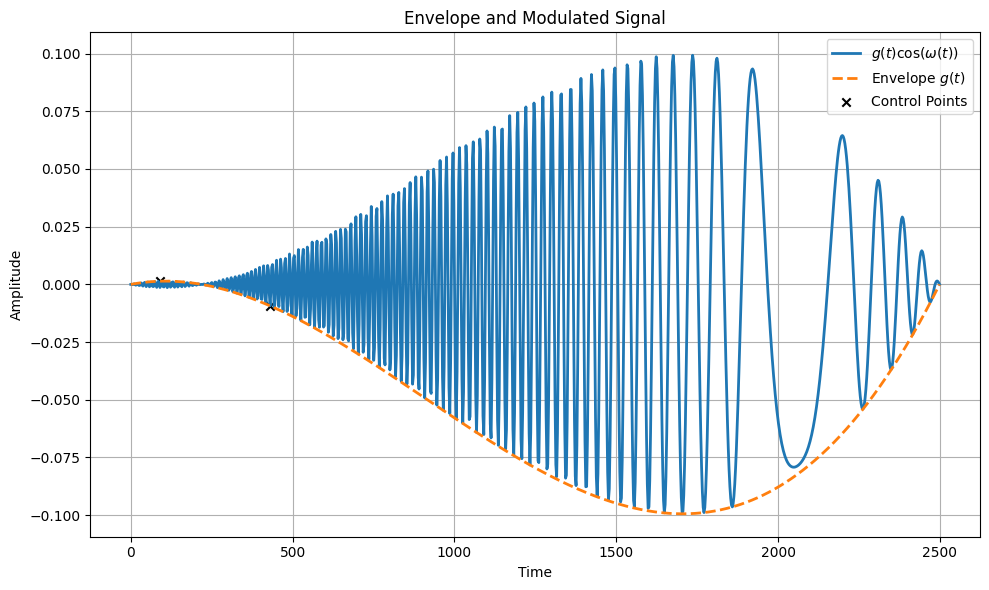

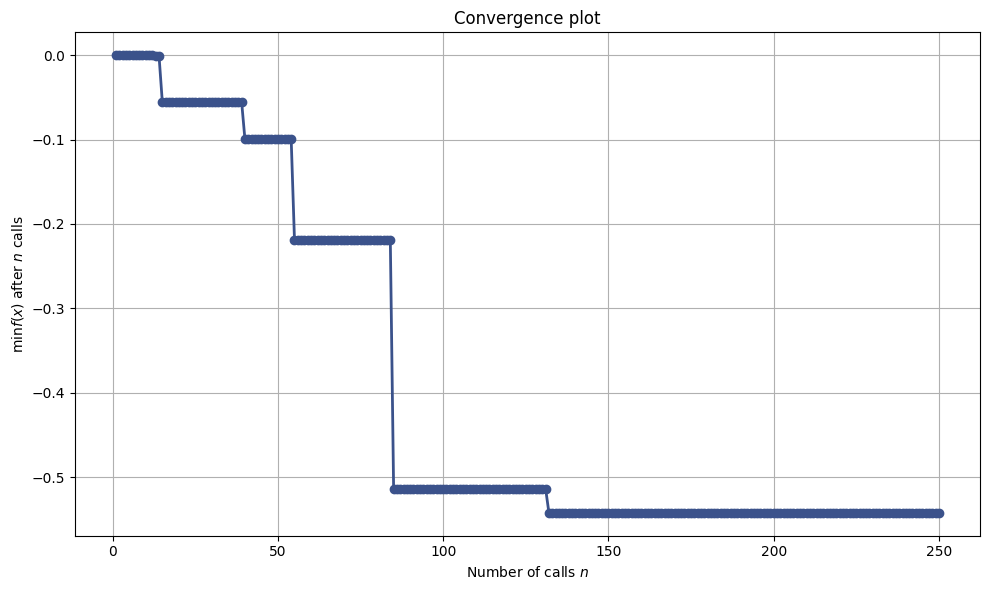

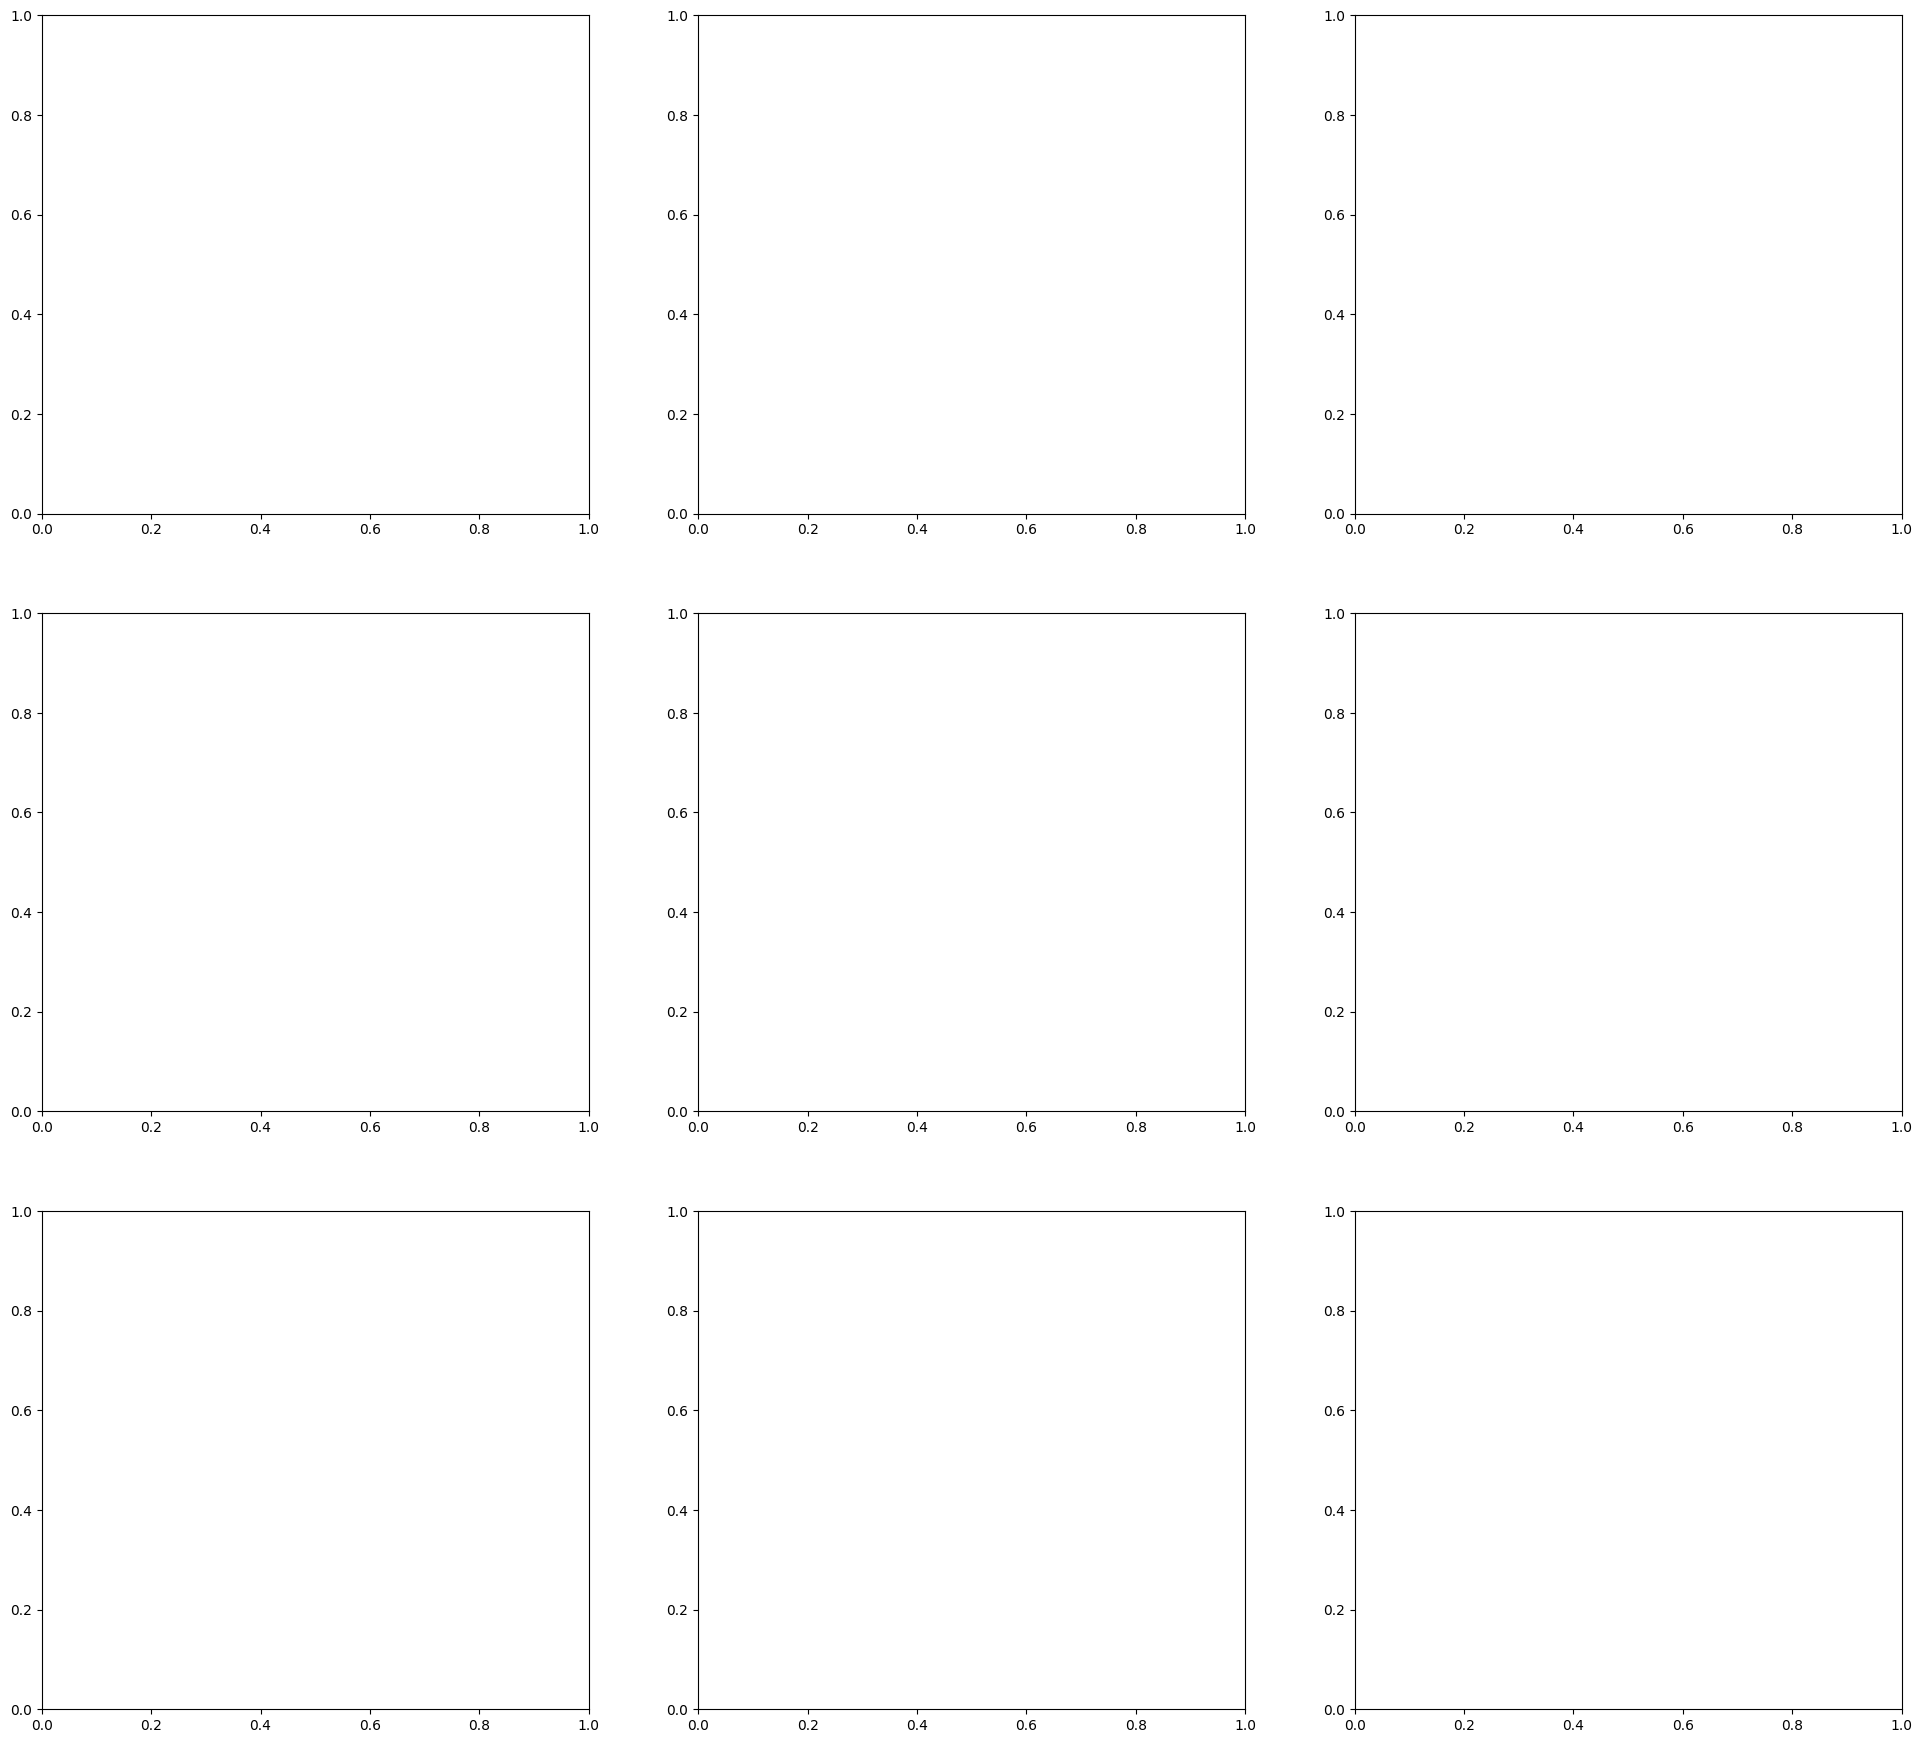

In [30]:
# Define your search space with normalized time deltas
space = [
    Real(-g, g),         # envelope_y1
    Real(-g, g),         # envelope_y2
    Real(0, 1),          # delta_ex1
    Real(0, 1),          # delta_ex2
    Real(1/g, 3000),     # sim_time
    Real(0.1, 1.0),      # freq1
    Real(0.1, 1.0),      # freq2
    Real(0, 0.5),        # fx1
    Real(0, 0.5),        # fx2
]

def run_optimization_and_analysis(f_t, space, plot=True, n_calls=250, random_state=42):
    def objective_general(envelope_y1, envelope_y2, delta_ex1, delta_ex2, sim_time,
                          freq1, freq2, fx1, fx2):

        tau = wc * sim_time
        envelope_x1 = tau * min(delta_ex1, delta_ex2)
        envelope_x2 = tau * max(delta_ex1, delta_ex2)

        freq_x1 = tau * fx1
        freq_x2 = tau * (fx1 + fx2)

        if not (0 < envelope_x1 < envelope_x2 < tau):
            return 1.0
        if not (0 < freq_x1 < freq_x2 < tau):
            return 1.0

        envelope_values = [0, envelope_y1, envelope_y2, 0]
        control_times = [0, envelope_x1, envelope_x2, tau]
        spline = CubicSpline(control_times, envelope_values, extrapolate=False)

        freq_times = [freq_x1, freq_x2]
        freq_values = [freq1, freq2]
        frequency_spline = PchipInterpolator(freq_times, freq_values)

        args = {'envelope': spline, 'frequency': frequency_spline, 'sim_time': sim_time}

        H_static = delta_c * a.dag() * a + 0.5 * delta_a * sigma_z + (g / wc) * (sigma_plus * a + sigma_minus * a.dag())
        H_drive = [0.5 * (sigma_plus + sigma_minus), lambda t: f_t(t, args)]
        H = [H_static, H_drive]

        try:
            result = mesolve(H, psi_den, [0, tau], c_ops=[], e_ops=[],
                             options={'nsteps': 1e8, 'atol': 1e-7, 'rtol': 1e-7})
            final_rho = result.states[-1]
            fid = fidelity(final_rho, target_den)
            return -fid
        except Exception as e:
            print("Simulation error:", e)
            return 1.0

    def objective(x):
        return objective_general(*x)

    res = gp_minimize(objective, space, n_calls=n_calls, random_state=random_state, verbose=True, acq_func='EI')

    if plot:
        (Y1, Y2, delta_X1, delta_X2, sim_time,
         freq1, freq2, fx1, fx2) = res.x

        tau = wc * sim_time
        X1 = tau * min(delta_X1, delta_X2)
        X2 = tau * max(delta_X1, delta_X2)
        freq_x1 = tau * fx1
        freq_x2 = tau * (fx1 + fx2)

        tau_arr = np.linspace(0, tau, 1000)
        envelope_spline = CubicSpline([0, X1, X2, tau], [0, Y1, Y2, 0], extrapolate=False)
        frequency_spline = PchipInterpolator([freq_x1, freq_x2], [freq1, freq2])
        envelope = envelope_spline(tau_arr)
        omega_t = frequency_spline(tau_arr)

        # Plot 1: Modulated wave and envelope
        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, envelope * np.cos(omega_t * tau_arr), label=r'$g(t)\cos(\omega(t))$', linewidth=2)
        plt.plot(tau_arr, envelope, label=r'Envelope $g(t)$', linestyle='--', linewidth=2)
        plt.scatter([X1, X2], [Y1, Y2], marker='x', color='black', label='Control Points')
        plt.title('Envelope and Modulated Signal')
        plt.xlabel('Time')
        plt.ylabel('Amplitude')
        plt.grid(True)
        plt.legend(loc='best')
        plt.tight_layout()

        # Plot 2: Convergence
        plt.figure(figsize=(10, 6))
        plot_convergence(res)
        plt.tight_layout()

        # Plot 3: Objective landscape with shared colorbar
        fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(24, 22))  # 9 parameters → 3x3 grid
        contour_axes = plot_objective(
            res,
            dimensions=[
                'Y1', 'Y2', 'ΔX1', 'ΔX2', 'SimTime',
                'Freq1', 'Freq2', 'FX1', 'FX2'
            ],
            ax=ax, n_points=20, levels=20
        )


        # Plot 4: Population dynamics
        args = {'envelope': envelope_spline, 'frequency': frequency_spline}
        H_static = delta_c * a.dag() * a + 0.5 * delta_a * sigma_z + (g / wc) * (sigma_plus * a + sigma_minus * a.dag())
        H_drive = [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t(t, args)]
        H = [H_static, H_drive]
        output = mesolve(H, psi, tau_arr, c_ops=[], e_ops=[a.dag() * a, sigma_plus * sigma_minus], args=args)
        n_c = output.expect[0]
        n_a = output.expect[1]

        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, n_c, label='Cavity Photon Number')
        plt.plot(tau_arr, n_a, label='Atom Excited State')
        plt.xlabel('Time')
        plt.ylabel('Occupation')
        plt.legend(loc='best')
        plt.grid(True)
        plt.tight_layout()

        # Plot 5: ω(t)
        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, omega_t, label=r'$\omega(t)$', linewidth=2)
        plt.scatter([freq_x1, freq_x2], [freq1, freq2], marker='x', color='red', s=100, label='Parameterisation Points')
        plt.title('Time-Dependent Frequency')
        plt.xlabel('Time')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.legend(loc='best')
        plt.tight_layout()

    return res

# Now call the function
res = run_optimization_and_analysis(f_t, space)


In [ ]:

kappa = 1e-4 * wc  # Photon decay rate

c_ops = [np.sqrt(kappa) * a]  # Collapse operator for photon loss

psi = tensor(fock(n_cavity, 0), spin_down)
psi_den = psi * psi.dag()
target_state = tensor(fock(n_cavity, 2), spin_down)
target_den = target_state * target_state.dag()

def f_t(t, args):
    envelope_func = args['envelope']
    freq_func = args['frequency']
    omega_t = freq_func(t)
    return envelope_func(t) * np.cos(omega_t * t)

def run_optimization_and_analysis(f_t, space, plot=True, n_calls=300, random_state=42):
    def objective_general(envelope_y1, envelope_x1, envelope_y2, envelope_x2, sim_time,
                          freq1, freq2, freq3, freq_x1, freq_x2, freq_x3):

        tau = wc * sim_time

        if not (0 < envelope_x1 < envelope_x2 < tau):
            return 10.0
        if not (0 <= freq_x1 < freq_x2 < freq_x3 <= tau):
            return 10.0

        envelope_values = [0, envelope_y1, envelope_y2, 0]
        control_times = [0, envelope_x1, envelope_x2, tau]
        envelope_spline = CubicSpline(control_times, envelope_values, extrapolate=False)

        freq_times = [freq_x1, freq_x2, freq_x3]
        freq_values = [freq1, freq2, freq3]
        frequency_spline = CubicSpline(freq_times, freq_values, bc_type='not-a-knot')

        args = {'envelope': envelope_spline, 'frequency': frequency_spline, 'sim_time': sim_time}

        H_static = delta_c * a.dag() * a + 0.5 * delta_a * sigma_z + (g / wc) * (sigma_plus * a + sigma_minus * a.dag())
        H_drive = [0.5 * (sigma_plus + sigma_minus), lambda t: f_t(t, args)]
        H = [H_static, H_drive]

        result = mesolve(H, psi_den, [0, tau], c_ops=c_ops, e_ops=[], options={'nsteps': 1e6, 'atol': 1e-6, 'rtol': 1e-5})
        final_rho = result.states[-1]
        fid = fidelity(final_rho, target_den)
        return -fid

    def objective(x):
        return objective_general(*x)

    res = gp_minimize(objective, space, n_calls=n_calls, random_state=random_state, verbose=True, acq_func='EI')

    if plot:
        (Y1, X1, Y2, X2, sim_time,
         freq1, freq2, freq3, freq_x1, freq_x2, freq_x3) = res.x

        tau = np.linspace(0, sim_time, 1000)

        envelope_spline = CubicSpline([0, X1, X2, sim_time], [0, Y1, Y2, 0], extrapolate=False)
        frequency_spline = CubicSpline([freq_x1, freq_x2, freq_x3], [freq1, freq2, freq3], bc_type='not-a-knot')

        envelope = envelope_spline(tau)
        omega_t = frequency_spline(tau)
        modulated_wave = envelope * np.cos(omega_t * tau)

        # Plot 1: Modulated wave and envelope
        plt.figure(figsize=(10, 6))
        plt.plot(tau, modulated_wave, label='$g(t) \\cdot \\cos(\\omega(t) t)$', linewidth=2, color='royalblue')
        plt.plot(tau, envelope, label='Envelope $g(t)$', linestyle='--', color='red', linewidth=2)
        plt.scatter([X1, X2], [Y1, Y2], marker='x', color='black', label='Envelope Control Points')
        plt.title('Envelope and Frequency Modulated Signal (0 to 2, with Loss)')
        plt.xlabel('Time (arb. units)')
        plt.ylabel('Driving Amplitude')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig('envelope_modulated_wave_0_to_2_loss.png')
        plt.close()

        # Plot 2: Convergence
        plot_convergence(res)
        plt.savefig('convergence_0_to_2_loss.png')
        plt.close()

        # Plot 3: Objective landscape
        fig, ax = plt.subplots(figsize=(18, 14))
        plot_objective(res, dimensions=[
            'Y1', 'X1', 'Y2', 'X2', 'Simulation Time',
            'Freq1', 'Freq2', 'Freq3', 'Freq X1', 'Freq X2', 'Freq X3'
        ], ax=ax)
        plt.tight_layout()
        plt.savefig('objective_landscape_0_to_2_loss.png')
        plt.close()

        # Plot 4: Population dynamics
        psi = tensor(fock(n_cavity, 0), spin_down)
        args = {'envelope': envelope_spline, 'frequency': frequency_spline}
        H_drive = [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t(t, args)]
        H_static = delta_c * a.dag() * a + 0.5 * delta_a * sigma_z + (g / wc) * (sigma_plus * a + sigma_minus * a.dag())
        H = [H_static, H_drive]
        output = mesolve(H, psi, tau, c_ops=c_ops, e_ops=[a.dag() * a, sigma_plus * sigma_minus], args=args)
        n_c = output.expect[0]
        n_a = output.expect[1]

        plt.figure(figsize=(10, 6))
        plt.plot(tau, n_c, label='Cavity Photon Number')
        plt.plot(tau, n_a, label='Atom Excited State')
        plt.grid(True)
        plt.xlabel('Time (arb. units)')
        plt.ylabel('Occupation')
        plt.legend(loc='best')
        plt.tight_layout()
        plt.savefig('population_dynamics_0_to_2_loss.png')
        plt.close()

        # Plot 5: ω(t) (Frequency vs Time)
        plt.figure(figsize=(10, 6))
        plt.plot(tau, omega_t, label='ω(t)', linewidth=2, color='green')
        plt.title('Time-Dependent Frequency ω(t) (0 to 2, with Loss)')
        plt.xlabel('Time (arb. units)')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.savefig('frequency_profile_0_to_2_loss.png')
        plt.close()

        # Save best parameters to file
        with open("best_params_0_to_2_loss.txt", "w") as f:
            f.write("# Best parameters found by Bayesian optimization (0 → 2, with photon loss):\n")
            param_names = [
                "env_Y1", "env_X1", "env_Y2", "env_X2", "sim_time",
                "freq_Y1", "freq_Y2", "freq_Y3",
                "freq_X1", "freq_X2", "freq_X3"
            ]
            for name, val in zip(param_names, res.x):
                f.write(f"{name}: {val:.10f}\n")

    return res

space = [
    Real(0, g),           # Envelope Y1
    Real(0, 5000),        # Envelope X1
    Real(0, g),           # Envelope Y2
    Real(0, 5000),        # Envelope X2
    Real(0, 5000),        # Simulation time
    Real(0, 1.0),         # Frequency Y1
    Real(0, 1.0),         # Frequency Y2
    Real(0, 1.0),         # Frequency Y3
    Real(0, 5000),        # Frequency X1
    Real(0, 5000),        # Frequency X2
    Real(0, 5000),        # Frequency X3
]

res = run_optimization_and_analysis(f_t, space)
